In [1]:
import sys, os
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

import torch
from functions import load_triplet_dataset, collate_triplets
from utils.processing import sparse_to_dense
import matplotlib.pyplot as plt

In [2]:
save_path = "/home/ximeng/Documents/SparseCLIP/expired/nuscenes_triplet_val.pt"
dataset = load_triplet_dataset(save_path)
print(f"Loaded triplet dataset with {len(dataset)} samples.")

Loaded triplet dataset with 67677 samples.


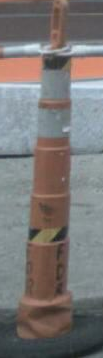

In [3]:
dataset[0][1]

In [4]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda batch: collate_triplets(batch, sparse_to_dense_fn=sparse_to_dense)
)

for batch in dataloader:
    break

print(f"Batch labels: {batch[0]}")
print(f"Batch image shape: {batch[1].shape}")
print(f"Batch point clouds shape: {batch[2].shape}")

Batch labels: ['a pointcloud of a car', 'a pointcloud of a truck']
Batch image shape: torch.Size([2, 3, 224, 224])
Batch point clouds shape: torch.Size([2, 1024, 3])


In [5]:
imgs = batch[1]  # [B, 3, H, W]
print("Image tensor shape:", imgs.shape)

print("min:", imgs.min().item())
print("max:", imgs.max().item())

Image tensor shape: torch.Size([2, 3, 224, 224])
min: -1.7922625541687012
max: 2.1458969116210938


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Label:  a pointcloud of a car


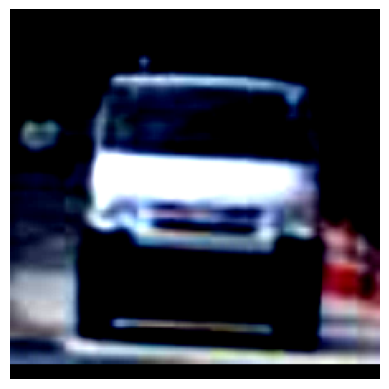

In [6]:
print("Label: ", batch[0][0])
img = batch[1][0].permute(1, 2, 0).numpy()
plt.imshow(img)
plt.axis('off')
plt.show()